# 06 · Interval extensions, dependency, and subdivision

**Time:** 100–120 minutes. **Prerequisites:** Lectures 04–05.
**Lab:** [Compare range enclosures](../labs/lab06_dependency.ipynb).

Objectives: distinguish the true range from an inclusion function, explain
dependency, prove exclusion, and enclose a whole domain by a finite covering.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.enclosures import subdivide, range_enclosure
from vc.arb_bridge import evaluate_ball

## THEORY · An enclosure need not be the exact range

For a real function f, the range on X is $f(X)=\{f(x):x\in X\}$.
An **inclusion function** F satisfies $f(X)\subseteq F(X)$ on its admissible
intervals. A natural interval extension follows an expression's operations,
replacing real operations by interval ones. Its width reflects both actual
variation and any overestimation introduced by the computation.

**Inclusion isotonicity** means $X\subseteq Y\Rightarrow F(X)\subseteq F(Y)$.
Exact endpoint operations and their well-defined natural compositions have this
property: restricting possible operands cannot introduce new real results, and
the endpoint formulas preserve the order of the bounds. Inclusion of the true
range follows by the composition argument from Lecture 04.

These properties are distinct. A valid enclosure method need not be isotonic;
changing arithmetic precision or representation need not give nested results.

## EXPERIMENT · One polynomial, three extensions

Over the reals, all three expressions below equal $f(x)=x(1-x)$. Over intervals,
the repetition of an unknown and the chosen operations affect the result.

In [3]:
def expanded_form(X):
    return X - X.square()

def product_form(X):
    return X * (1 - X)

def vertex_form(X):
    shifted = X - Fraction(1, 2)
    return Fraction(1, 4) - shifted.square()

domain = Interval(0, 1)
print("x - x²:", expanded_form(domain))
print("x(1-x):", product_form(domain))
print("1/4 - (x-1/2)²:", vertex_form(domain))

x - x²: [-1, 1]
x(1-x): [0, 1]
1/4 - (x-1/2)²: [0, 1/4]


On [0,1], $(x-1/2)^2$ lies in [0,1/4], with both extremes attained. Therefore
the true range is [0,1/4]. The first two enclosures are valid but wider. Here
the vertex form is sharp because it exposes a single squared variable.

**EXERCISE (10 minutes):** predict the three results on [0,1/4], then check them.
Will the same form always be best for every function and domain?

## THEORY + EXPERIMENT · Exclusion is a one-way implication

If $0\notin F(X)$, the function cannot vanish in X. **Proof:** a root would
contribute the value zero to f(X), contradicting $f(X)\subseteq F(X)$.

If zero belongs to F(X), the test is inconclusive. In particular, a wide natural
evaluation can contain zero even when the function is strictly positive.

In [4]:
X = Interval(-1, 1)
wide = X * X + 1
sharp = X.square() + 1
print("Independent product:", wide, "contains zero:", wide.contains(0))
print("Dedicated square:", sharp, "contains zero:", sharp.contains(0))
assert sharp.lo > 0
print("Certificate: x² + 1 > 0 throughout [-1,1].")

Independent product: [0, 2] contains zero: True
Dedicated square: [1, 2] contains zero: False
Certificate: x² + 1 > 0 throughout [-1,1].


## THEORY · A finite covering gives a global enclosure

Suppose $X=X_1\cup\cdots\cup X_n$ and each $F(X_i)$ encloses f on that piece.
Then

$$f(X)\subseteq\bigcup_i F(X_i)\subseteq
[\min_i\operatorname{lo}F(X_i),\max_i\operatorname{hi}F(X_i)].$$

**Proof.** Every x in X belongs to at least one piece, so its value belongs to
that piece's image enclosure. Taking the hull can only enlarge the set.
Shared endpoints cause no problem for a range bound. Omitting a gap would.

The code uses exact rational midpoints to preserve domain coverage. More pieces
cost more evaluations, and a wide final range may reflect genuine variation.

In [5]:
def enclosure_by_pieces(evaluate, domain, depth):
    pieces = subdivide(domain, depth)
    result = evaluate(pieces[0])
    for piece in pieces[1:]:
        local_result = evaluate(piece)
        result = result.hull(local_result)
    return result

for depth in range(6):
    bound = enclosure_by_pieces(product_form, domain, depth)
    excess_width = bound.width() - Fraction(1, 4)
    print("depth:", depth, "pieces:", 2**depth,
          "range:", bound, "excess width:", excess_width)
    assert Interval(0, "1/4").is_subset_of(bound)

depth: 0 pieces: 1 range: [0, 1] excess width: 3/4
depth: 1 pieces: 2 range: [0, 1/2] excess width: 1/4
depth: 2 pieces: 4 range: [0, 3/8] excess width: 1/8
depth: 3 pieces: 8 range: [0, 5/16] excess width: 1/16
depth: 4 pieces: 16 range: [0, 9/32] excess width: 1/32
depth: 5 pieces: 32 range: [0, 17/64] excess width: 1/64


We know the exact range here, so we can quantify overestimation. For a general
function, a sample minimum and maximum are not an exact reference range.

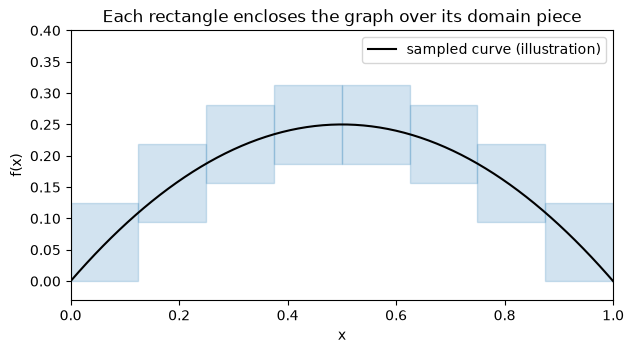

In [6]:
pieces = subdivide(domain, 3)
fig, ax = plt.subplots(figsize=(7, 3.5))
for piece in pieces:
    image = product_form(piece)
    rectangle = Rectangle((float(piece.lo), float(image.lo)),
                          float(piece.width()), float(image.width()),
                          facecolor="tab:blue", edgecolor="tab:blue", alpha=0.2)
    ax.add_patch(rectangle)
xs = np.linspace(0, 1, 201)
ax.plot(xs, xs*(1-xs), color="black", label="sampled curve (illustration)")
ax.set(xlim=(0, 1), ylim=(-0.03, 0.4), xlabel="x", ylabel="f(x)",
       title="Each rectangle encloses the graph over its domain piece")
ax.legend()
display(fig)
plt.close(fig)

## EXPERIMENT · More arithmetic bits do not remove dependency

Even exact rational endpoint arithmetic produced [0,1] for the product form on
[0,1]. Thus that width was not caused by rounding. Increasing precision cannot
recover the relation between the occurrences of x. Reformulation and subdivision
attack a different source of overestimation than arithmetic precision does.

## EXPERIMENT · Elementary functions through Arb

For f(x) = (sin(x) − x² + 1) cos(x) on [0,1/2], an elementary inclusion
computation can already exclude zero. This is adapted from Tucker, Example 3.1.4.
The callback must use Arb operations throughout; the bridge returns rational
endpoint bounds so our certificate comparisons remain exact.

In [7]:
def trigonometric_function(x):
    sine = x.sin()
    cosine = x.cos()
    return (sine - x*x + 1) * cosine

trig_domain = Interval(0, "1/2")
bound = evaluate_ball(trigonometric_function, trig_domain, precision=100)
assert bound.lo > 0
print("Rigorous lower bound, displayed approximately:", float(bound.lo))
print("Certificate: the function is positive on [0,1/2].")

Rigorous lower bound, displayed approximately: 0.605888622461185
Certificate: the function is positive on [0,1/2].


The assertion uses the exact rational lower endpoint, not its decimal display.
The claim depends on Arb's rigorous operations and the function's being defined
on the input ball, which may be slightly wider than the original interval.

## Failure case · A mathematical domain restriction

The expression x/x equals 1 for nonzero x, but the original expression is
undefined at zero. Replacing it by a constant on a domain containing zero would
change the mathematical problem. Similarly, interval evaluation of log requires
a suitable positive input enclosure.

In [8]:
def logarithm(x):
    return x.log()

try:
    evaluate_ball(logarithm, Interval(-2, -1))
except ValueError as error:
    print("No finite real enclosure returned:", error)

No finite real enclosure returned: Nonfinite Arb result: check the function domain or precision


## Recap and reading

An enclosure is a set guarantee; sharpness is a separate question. A useful
range method combines valid local evaluations with complete domain coverage.
A failure to exclude zero does not prove a root, and numerical samples do not
replace covering arguments.

**Exit ticket:** explain which of precision, reformulation, and subdivision
addresses rounding error, variable dependency, and actual function variation.

**Reading:** Tucker §3.1, pp. 46–54; Examples 3.1.1–3.1.4 and Theorem 3.8.
Next: [Lecture 07](07_better_enclosures.ipynb).